# 정답지 만들기 — 모공·주름·색소·여드름

부위별로 정답이 있는 칸만 채운다. 없는 칸은 빈칸으로 두고, 학습할 때 loss에서 뺀다.

| | 이마 | 미간 | 눈가 좌/우 | 볼 좌/우 |
|---|:-:|:-:|:-:|:-:|
| 모공 | · | · | · | 등급 + **개수** |
| 주름 | 등급 | 등급 | 등급 + **Ra** | · |
| 색소 | 등급 | · | · | 등급 |
| 여드름 | **개수** | · | · | **개수** |
| 피부나이 | **나이** | **나이** | **나이** | **나이** |

- **굵은 글씨 = 기기 측정값·실제값**(객관적). 나머지는 사람이 매긴 등급이다.
- 피부나이의 정답은 **실제 나이**다. 부위마다 같은 값을 넣어 두고, 추론할 때 부위별 예측을 평균한다.
  "이 부위만 보면 몇 살로 보이는가"를 배우게 하는 셈이다.
- 학습 목표는 측정값이 있으면 측정값, 없으면 등급을 쓴다.
- 등급·측정값은 사람마다 한 세트다(각도·기기가 달라도 같다). 그래서 스마트폰 정면 라벨만 읽는다.
- **여드름만 예외**다. 좌표 목록이 디지털카메라 정면 사진에만 있어서, 그 사진에 랜드마크를 찍어
  좌표가 어느 부위에 들어가는지 세야 한다. 세 기기가 같은 날 촬영이라 폰·패드 사진에 붙여도 된다.

결과 파일 2개
- `data/02.정답지데이터/labels_region.csv` — 사람 × 부위 (965 × 6 = 5,790행). 학습이 쓰는 파일
- `data/02.정답지데이터/labels_face.csv` — 사람 단위 값 (여드름 총개수, 색소침착 개수, 나이·성별 등)

In [6]:
import csv
import importlib
import json
import time
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path as Polygon

import face_regions

importlib.reload(face_regions)  # face_regions.py 수정사항을 커널 재시작 없이 반영
from face_regions import DATA_DIR, create_landmarker, detect_landmarks, eye_bar_box, region_polygons

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

OUT_DIR = Path.cwd().parent / "data" / "02.정답지데이터"
REGIONS = ["forehead", "glabella", "l_eye", "r_eye", "l_cheek", "r_cheek"]

# 부위 → (라벨 파일 번호, 읽을 항목들)
#   항목 = (저장할 열 이름, 라벨 JSON의 키, annotations(등급) 또는 equipment(측정값))
FIELDS = {
    "forehead": (1, [("wrinkle_grade", "forehead_wrinkle", "annotations"),
                     ("pigment_grade", "forehead_pigmentation", "annotations")]),
    "glabella": (2, [("wrinkle_grade", "glabellus_wrinkle", "annotations")]),
    "l_eye": (3, [("wrinkle_grade", "l_perocular_wrinkle", "annotations"),
                  ("wrinkle_ra", "l_perocular_wrinkle_Ra", "equipment")]),
    "r_eye": (4, [("wrinkle_grade", "r_perocular_wrinkle", "annotations"),
                  ("wrinkle_ra", "r_perocular_wrinkle_Ra", "equipment")]),
    "l_cheek": (5, [("pore_grade", "l_cheek_pore", "annotations"),
                    ("pore_count", "l_cheek_pore", "equipment"),
                    ("pigment_grade", "l_cheek_pigmentation", "annotations")]),
    "r_cheek": (6, [("pore_grade", "r_cheek_pore", "annotations"),
                    ("pore_count", "r_cheek_pore", "equipment"),
                    ("pigment_grade", "r_cheek_pigmentation", "annotations")]),
}
REGION_COLUMNS = ["subject", "split", "region", "age", "pore_grade", "pore_count", "wrinkle_grade", "wrinkle_ra",
                  "pigment_grade", "acne_count"]
FACE_COLUMNS = ["subject", "split", "gender", "age", "skin_type", "sensitive",
                "acne_total", "acne_in_regions", "pigmentation_count"]

## 1. 등급·측정값 읽기

스마트폰 정면 라벨 파일에서 읽는다 (사람당 6개 파일).

In [7]:
labels = defaultdict(dict)  # (사람, 부위) → {열 이름: 값}
faces = {}  # 사람 → 사람 단위 값

for split in ["Training", "Validation"]:
    for subject_dir in sorted((DATA_DIR / split / "02.라벨링데이터" / "3. 스마트폰").iterdir()):
        if not subject_dir.is_dir():
            continue
        subject = subject_dir.name
        for region, (file_no, fields) in FIELDS.items():
            paths = sorted(subject_dir.glob(f"*_F_{file_no:02d}.json"))
            if not paths:
                continue
            label = json.loads(paths[0].read_text())
            for column, key, source in fields:
                value = (label[source] or {}).get(key)
                if value is not None:
                    labels[(subject, region)][column] = value

        # 사람 단위 값은 얼굴 전체 파일(00번)에서
        whole = json.loads(sorted(subject_dir.glob("*_F_00.json"))[0].read_text())
        faces[subject] = dict(subject=subject, split=split, gender=whole["info"]["gender"], age=whole["info"]["age"],
                              skin_type=whole["info"]["skin_type"], sensitive=whole["info"]["sensitive"],
                              pigmentation_count=(whole["equipment"] or {}).get("pigmentation_count"))

print(f"사람 {len(faces):,}명, 채워진 칸 {sum(len(v) for v in labels.values()):,}개")
example = next(iter(faces))
print(f"{example}번 예시:", {region: labels[(example, region)] for region in REGIONS})

사람 965명, 채워진 칸 12,545개
0002번 예시: {'forehead': {'wrinkle_grade': 1, 'pigment_grade': 1}, 'glabella': {'wrinkle_grade': 1}, 'l_eye': {'wrinkle_grade': 3, 'wrinkle_ra': 15.44}, 'r_eye': {'wrinkle_grade': 3, 'wrinkle_ra': 14.39}, 'l_cheek': {'pore_grade': 2, 'pore_count': 631.0, 'pigment_grade': 3}, 'r_cheek': {'pore_grade': 2, 'pore_count': 691.0, 'pigment_grade': 3}}


## 2. 여드름 — 좌표를 부위별 개수로

디지털카메라 정면 사진에 랜드마크를 찍고, 여드름 좌표가 어느 부위 다각형 안에 있는지 센다.
여드름이 없는 사람(`acne: None`)은 모든 부위가 0이다. 3~5분 걸린다.

In [8]:
acne_counts = {}  # 사람 → {부위: 개수}
acne_totals = {}  # 사람 → (전체 개수, 6부위 안에 든 개수)
failed = []

started = time.time()
with create_landmarker() as landmarker:
    for split in ["Training", "Validation"]:
        label_root = DATA_DIR / split / "02.라벨링데이터" / "1. 디지털카메라"
        image_root = DATA_DIR / split / "01.원천데이터" / "1. 디지털카메라"
        for subject_dir in sorted(label_root.iterdir()):
            if not subject_dir.is_dir():
                continue
            subject = subject_dir.name
            paths = sorted(subject_dir.glob("*_F_00.json"))
            if not paths:
                continue
            spots = json.loads(paths[0].read_text())["annotations"]["acne"]

            if not spots:  # 여드름 없음 → 모든 부위 0
                acne_counts[subject] = {region: 0 for region in REGIONS}
                acne_totals[subject] = (0, 0)
                continue

            image_path = image_root / subject / f"{paths[0].stem[:-3]}.jpg"
            bgr = cv2.imread(str(image_path))
            points = detect_landmarks(landmarker, bgr) if bgr is not None else None
            if points is None:  # 랜드마크 실패 → 부위를 알 수 없으므로 빈칸
                failed.append(subject)
                continue

            polygons = region_polygons(points, eye_bar_box(bgr, points))
            counts = {region: 0 for region in REGIONS}
            for spot in spots:
                for region, polygon in polygons.items():
                    if Polygon(polygon).contains_point(spot["points"]):
                        counts[region] += 1
                        break  # 부위끼리 겹치지 않으므로 처음 찾으면 끝
            acne_counts[subject] = counts
            acne_totals[subject] = (len(spots), sum(counts.values()))

print(f"{time.time() - started:.0f}초 | 처리 {len(acne_counts):,}명, 랜드마크 실패 {len(failed)}명 {failed[:5]}")
total_spots = sum(t[0] for t in acne_totals.values())
inside = sum(t[1] for t in acne_totals.values())
print(f"여드름 {total_spots:,}개 중 6부위 안 {inside:,}개 ({inside / total_spots * 100:.0f}%) — 나머지는 코·턱·입 주변")
print("부위별 합계:", {r: sum(c[r] for c in acne_counts.values()) for r in REGIONS})
print(f"여드름이 있는 사람: {sum(1 for t in acne_totals.values() if t[0] > 0):,}명 / {len(acne_totals):,}명")

W0000 00:00:1790163623.107348 1789993 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1790163623.116081 1789993 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
W0000 00:00:1790163623.117069 1789997 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790163623.126949 1789997 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


41초 | 처리 965명, 랜드마크 실패 0명 []
여드름 3,226개 중 6부위 안 2,218개 (69%) — 나머지는 코·턱·입 주변
부위별 합계: {'forehead': 1220, 'glabella': 44, 'l_eye': 34, 'r_eye': 34, 'l_cheek': 421, 'r_cheek': 465}
여드름이 있는 사람: 576명 / 965명


## 3. 저장

여드름은 이마·볼 좌/우만 쓴다. 미간·눈가는 거의 전부 0이라 학습에 도움이 안 된다.

In [9]:
ACNE_REGIONS = ["forehead", "l_cheek", "r_cheek"]

OUT_DIR.mkdir(parents=True, exist_ok=True)
region_rows = []
for subject, face in sorted(faces.items()):
    for region in REGIONS:
        # 나이는 부위에 상관없이 같은 값 (부위별 예측을 평균해 피부나이를 낸다)
        row = dict(subject=subject, split=face["split"], region=region, age=face["age"],
                   **labels[(subject, region)])
        if region in ACNE_REGIONS and subject in acne_counts:
            row["acne_count"] = acne_counts[subject][region]
        region_rows.append(row)

with open(OUT_DIR / "labels_region.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=REGION_COLUMNS)
    writer.writeheader()
    writer.writerows(region_rows)

face_rows = []
for subject, face in sorted(faces.items()):
    total, in_regions = acne_totals.get(subject, (None, None))
    face_rows.append(dict(face, acne_total=total, acne_in_regions=in_regions))

with open(OUT_DIR / "labels_face.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=FACE_COLUMNS)
    writer.writeheader()
    writer.writerows(face_rows)

print(f"labels_region.csv  {len(region_rows):,}행")
print(f"labels_face.csv    {len(face_rows):,}행")
print("\n열별 채워진 칸 수 (빈칸 = 그 부위에 그 항목이 없음)")
for column in REGION_COLUMNS[3:]:
    filled = [r for r in region_rows if r.get(column) is not None]
    print(f"  {column:14s} {len(filled):5,d}개  {sorted({r['region'] for r in filled})}")

labels_region.csv  5,790행
labels_face.csv    965행

열별 채워진 칸 수 (빈칸 = 그 부위에 그 항목이 없음)
  age            5,790개  ['forehead', 'glabella', 'l_cheek', 'l_eye', 'r_cheek', 'r_eye']
  pore_grade     1,930개  ['l_cheek', 'r_cheek']
  pore_count     1,930개  ['l_cheek', 'r_cheek']
  wrinkle_grade  3,860개  ['forehead', 'glabella', 'l_eye', 'r_eye']
  wrinkle_ra     1,930개  ['l_eye', 'r_eye']
  pigment_grade  2,895개  ['forehead', 'l_cheek', 'r_cheek']
  acne_count     2,895개  ['forehead', 'l_cheek', 'r_cheek']


## 4. 분포 확인

학습 목표로 쓸 값들의 분포를 본다. 0이 많거나 한쪽으로 쏠려 있으면 학습이 어렵다.

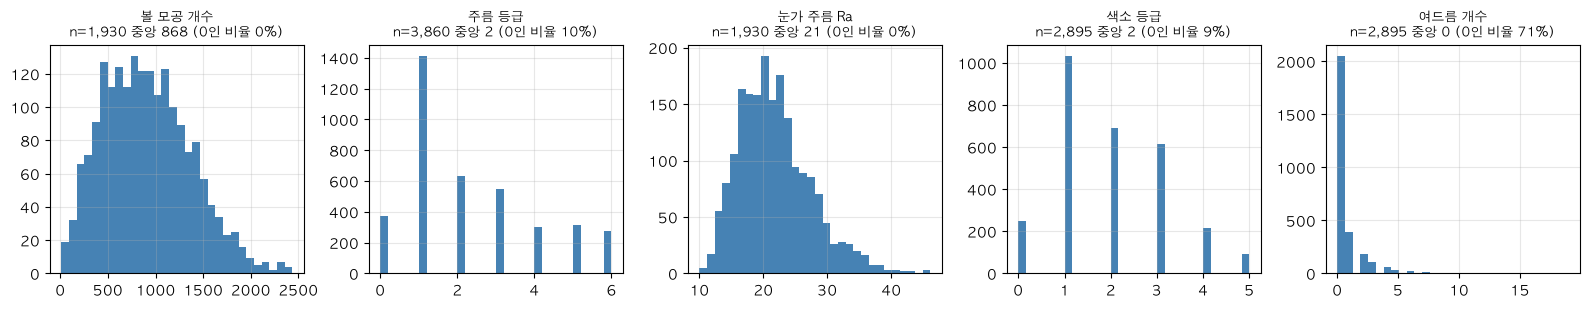

여드름 부위별 분포 (0이 많을수록 학습이 어렵다)
  forehead  평균 1.26개, 0인 비율 59%, 최대 19개  분포 {0: 570, 1: 137, 2: 74, 3: 68, 4: 41, 5: 23} ...
  l_cheek   평균 0.44개, 0인 비율 78%, 최대 14개  분포 {0: 750, 1: 122, 2: 52, 3: 17, 4: 10, 5: 7} ...
  r_cheek   평균 0.48개, 0인 비율 76%, 최대 17개  분포 {0: 735, 1: 128, 2: 57, 3: 19, 4: 8, 5: 5} ...


In [10]:
TARGETS = [("pore_count", "볼 모공 개수"), ("wrinkle_grade", "주름 등급"), ("wrinkle_ra", "눈가 주름 Ra"),
           ("pigment_grade", "색소 등급"), ("acne_count", "여드름 개수")]

fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 3.2))
for ax, (column, name) in zip(axes, TARGETS):
    values = np.array([float(r[column]) for r in region_rows if r.get(column) is not None])
    ax.hist(values, bins=30, color="steelblue")
    ax.set_title(f"{name}\nn={len(values):,} 중앙 {np.median(values):.0f} (0인 비율 {(values == 0).mean() * 100:.0f}%)",
                 fontsize=9)
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

print("여드름 부위별 분포 (0이 많을수록 학습이 어렵다)")
for region in ACNE_REGIONS:
    values = [r["acne_count"] for r in region_rows if r["region"] == region and r.get("acne_count") is not None]
    counts = Counter(values)
    print(f"  {region:9s} 평균 {np.mean(values):.2f}개, 0인 비율 {values.count(0) / len(values) * 100:.0f}%, "
          f"최대 {max(values)}개  분포 {dict(sorted(counts.items())[:6])} ...")